# Pre Processing the Data

In [1]:
# Install libraries
# !pip install openpyxl
# !pip install numpy 
# !pip install pandas 
# !pip install matplotlib
# !pip install seaborn
# !pip install statsmodels
# !pip install pmdarima
# Import libraries 
# Standard libraries

import numpy as np 
import pandas as pd 
import matplotlib.pyplot as plt
import seaborn as sns 
import statsmodels.api as sm

# Diagnostics
from statsmodels.tsa.arima.model import ARIMA
from statsmodels.graphics.tsaplots import plot_acf, plot_pacf
from statsmodels.tsa.stattools import adfuller, kpss
from statsmodels.stats.diagnostic import acorr_ljungbox
from statsmodels.stats.diagnostic import het_arch
from statsmodels.stats.stattools import jarque_bera
from statsmodels.stats.outliers_influence import variance_inflation_factor
from statsmodels.stats.diagnostic import het_breuschpagan
from statsmodels.stats.stattools import durbin_watson

# Model Selection
import pmdarima as pm


In [2]:


# Daily
d = pd.read_excel(
    "/Users/ivanhung/Documents/GitHub/financial-econometrics-cw/files/oil_data.xlsx",
    sheet_name=1
)

# Weekly
w = pd.read_excel(
    "/Users/ivanhung/Documents/GitHub/financial-econometrics-cw/files/oil_data.xlsx",
    sheet_name=2
)

# Monthly
m = pd.read_excel(
    "/Users/ivanhung/Documents/GitHub/financial-econometrics-cw/files/oil_data.xlsx",
    sheet_name=3
)

# Macroeconomic Factors
macro = pd.read_excel(
    "/Users/ivanhung/Documents/GitHub/financial-econometrics-cw/files/oil_data.xlsx",
    sheet_name=4
)

# Prices of various oil equities and indexes
prices = pd.read_excel(
    "/Users/ivanhung/Documents/GitHub/financial-econometrics-cw/files/oil_data.xlsx",
    sheet_name=5
)

# Verify if the data loaded in correctly 
# d.head()
# w.head()
# m.head()
# macro.head()
# prices.head()

# Sort time-series so that it is in order 
d = d.sort_values("Date")
w = w.sort_values("Date")
m = m.sort_values("Date")
macro = macro.sort_values("Date")
prices = prices.sort_values("Date")

# Checking the datatypes to ensure that date has been time-series set
# m.dtypes

# Preparing the Data for Forecasting
## Selecting our dependent variable
We choose to make our dependent variable the CL2-CL1 spread as it is economically the most valuable for understanding the oil market. We hope that our results can help us to further understand the seasonality structure that is found in the oil market. Using spreads helps us to capture seasonlity, which isn't captured in prices (as it comes up as white noise), for factors such as, geopolitical risk, macro shocks, financial flows and USD movements (FX market).

We deicde to use monthly prices to construct our spread variables in order to ensure consistency across the information set. While a weekly frequency would be preferable given the trading horizon, the majority of economically informative explanatory variables in the dataset are observed at a monthly frequency. Aligning prices to this frequency avoids temporal misalignment, reducing the risk of introducing spurious dynamics into the model. Monthly prices also mitigates the impact of high-frequency noise, which is particularly common in oil markets due to their inherent volatility. Therefore, we exclude utilising daily prices as their short-term fluctuations are unlikely to provide stable predictive content for medium-horizon forecasts.

In [3]:
"""
We construct a monthly futures spread as the difference between the second-month (CL2) and first-month (CL1) 
WTI crude oil futures contracts, defined as CL2 - CL1.

Note: 
- CL1 > CL2 = Backwardation [supply shortage]
- CL1 < CL2 = Contango [excess supply]
"""

m["spread"] = m["CL2"] - m["CL1"]
m["spread_change"] = m["spread"].diff()

m.head()

,Date,CL1,CL2,Brent,CRKS321C Index,Baltic Dry Index,Daily Production,Inventories,Rig Count,Commercial Long,Commercial Short,Total Open Interest,spread,spread_change
354,1994-12-30,17.76,17.71,16.50,2.387,1965,6675,904519,791,288400,287502,575902,-0.05,NaN
353,1995-01-31,18.39,18.24,16.80,1.575,1973,6526,898253,731,287720,293477,581197,-0.15,-0.10
352,1995-02-28,18.49,18.35,16.87,1.870,2038,6546,896939,696,275392,287982,563374,-0.14,0.01
351,1995-03-31,19.17,18.95,17.50,2.474,2209,6380,912742,648,260845,271270,532115,-0.22,-0.08
350,1995-04-28,20.38,20.05,19.06,4.656,2347,6539,910037,680,268845,279756,548601,-0.33,-0.11


# Renaming Variables

In [4]:
# Rename columns for easier reference later
rename = {
    "Date": "date",
    "CL1": "cl1",
    "CL2": "cl2",
    "Brent": "brent",
    "CRKS321C Index": "crack_spread_321",
    "Baltic Dry Index": "baltic_dry_index",
    "Daily Production": "daily_production",
    "Inventories" : "inventories",
    "Rig Count" : "num_of_rigs",
    "Commercial Long" : "commercial_long",
    "Commercial Short" : "commercial_short",
    "Total Open Interest" : "total_open_interest",
    "spread" : "spread",
    "spread_change" : "spread_change",
}

m = m.rename(columns=rename)

m.head()

,date,cl1,cl2,Brent,crack_spread_321,baltic_dry_index,daily_production,inventories,num_of_rigs,commercial_long,commercial_short,total_open_interest,spread,spread_change
354,1994-12-30,17.76,17.71,16.50,2.387,1965,6675,904519,791,288400,287502,575902,-0.05,NaN
353,1995-01-31,18.39,18.24,16.80,1.575,1973,6526,898253,731,287720,293477,581197,-0.15,-0.10
352,1995-02-28,18.49,18.35,16.87,1.870,2038,6546,896939,696,275392,287982,563374,-0.14,0.01
351,1995-03-31,19.17,18.95,17.50,2.474,2209,6380,912742,648,260845,271270,532115,-0.22,-0.08
350,1995-04-28,20.38,20.05,19.06,4.656,2347,6539,910037,680,268845,279756,548601,-0.33,-0.11


# Defining our Target Variable

In [5]:
# Setting our target variable
y = m['spread']

# Visualizing Spreads

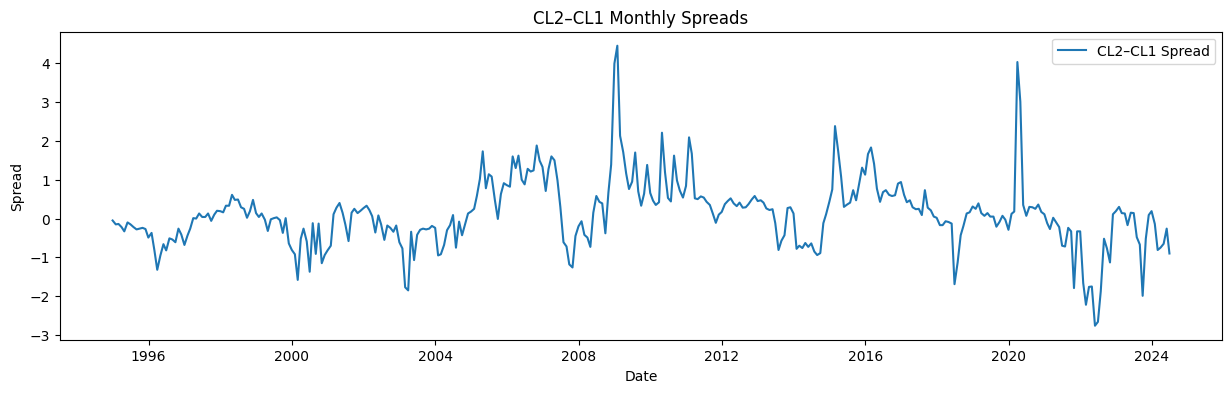

In [6]:
# Visulisaing spreads

plt.figure(figsize=(15, 4))
plt.plot(m["date"], y, label="CL2–CL1 Spread")
plt.xlabel("Date")
plt.ylabel("Spread")
plt.title("CL2–CL1 Monthly Spreads")
plt.legend()
plt.show()

# Diagnostics and Explanatory Variable Selection
 ## Splitting the data into training and testing set

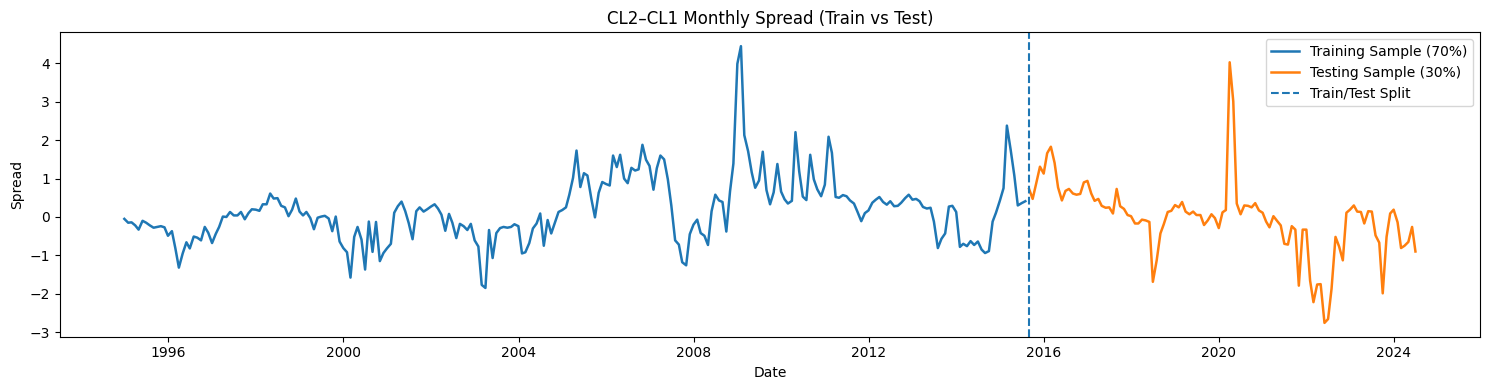

In [7]:
"""
Before we run any diagnostics and select any explanatory variables, we must start by splitting our data into a training 
and testing test. We should do this before running any diagonistics to prevent overfitting our data onto our testing 
sample and leading to unreliable out-of-sample results. 

We deice to utilise a 70:30 train:test split after observing the time-series plot above. The reason being that 
the training sample spans multiple market regimes, including periods of elevated volatility and structural stress, 
allowing the model to learn oil spread dynamics under diverse conditions. The test sample corresponds to a relatively 
stable regime, providing a rigourous evaluation of the model’s ability to generalise out of sample.
"""

# Create split slice
split = int(len(m) * 0.7)

# Creating training and testing sub-samples
m_train = m.iloc[:split]
m_test = m.iloc[split:]

y_train = m_train['spread']
y_test  = m_test['spread']


# Plot training data to confirm split works
# Plot full series with train/test split in different colours

plt.figure(figsize=(15, 4))

# Training sample
plt.plot(
    m_train["date"],
    m_train["spread"],
    label="Training Sample (70%)",
    linewidth=1.8
)

# Testing sample
plt.plot(
    m_test["date"],
    m_test["spread"],
    label="Testing Sample (30%)",
    linewidth=1.8
)

# Vertical line showing split point
plt.axvline(
    x=m_test["date"].iloc[0],
    linestyle="--",
    linewidth=1.5,
    label="Train/Test Split"
)

plt.xlabel("Date")
plt.ylabel("Spread")
plt.title("CL2–CL1 Monthly Spread (Train vs Test)")
plt.legend()
plt.tight_layout()
plt.show()

# Diagnostic Tests (Stationarity)

In [8]:
# Test for Stationarity (ADF and KPSS Test)

# ADF
adf_result = adfuller(m_train["spread"].dropna())

print("ADF Statistic:", adf_result[0])
print("p-value:", adf_result[1])
print("Critical Values:")
for key, value in adf_result[4].items():
    print(f"  {key}: {value}")


# KPSS
kpss_stat, kpss_pvalue, lags, crit = kpss(
    m_train["spread"].dropna(),
    regression="c",   # "c" = level stationarity, "ct" = trend stationarity
    nlags="auto"
)

print("KPSS Statistic:", kpss_stat)
print("p-value:", kpss_pvalue)
print("Critical Values:")
for key, value in crit.items():
    print(f"  {key}: {value}")

ADF Statistic: -5.013191658862977
p-value: 2.0896978174606067e-05
Critical Values:
  1%: -3.457105309726321
  5%: -2.873313676101283
  10%: -2.5730443824681606
KPSS Statistic: 0.6545686403723567
p-value: 0.017675578147967566
Critical Values:
  10%: 0.347
  5%: 0.463
  2.5%: 0.574
  1%: 0.739


In [9]:
# Test for Stationarity (ADF and KPSS Test)

# Create a function for ADF and KPSS Test 
def stationarity_sum(series, name=""):
    series = series.dropna()

    adf = adfuller(series)
    kpss_stat, kpss_p, _, kpss_crit = kpss(series, regression="c", nlags="auto")

    print(f"\n{name}")
    print("-" * len(name))
    print(f"ADF p-value  : {adf[1]:.4f}")
    print(f"KPSS p-value : {kpss_p:.4f}")


stationarity_sum(m_train["spread"], "CL2-CL1 Spread")


CL2-CL1 Spread
--------------
ADF p-value  : 0.0000
KPSS p-value : 0.0177


In [10]:
# Difference the time-series
spread_d = m_train["spread"].diff().dropna()

stationarity_sum(spread_d, "CL2-CL1 Spread (Differenced)")


CL2-CL1 Spread (Differenced)
----------------------------
ADF p-value  : 0.0000
KPSS p-value : 0.1000


/var/folders/by/g895l7l128j9y19qqn66xcxh0000gn/T/ipykernel_20367/3285853403.py:8: InterpolationWarning: The test statistic is outside of the range of p-values available in the
look-up table. The actual p-value is greater than the p-value returned.

  kpss_stat, kpss_p, _, kpss_crit = kpss(series, regression="c", nlags="auto")


# Plotting ACF and PACF

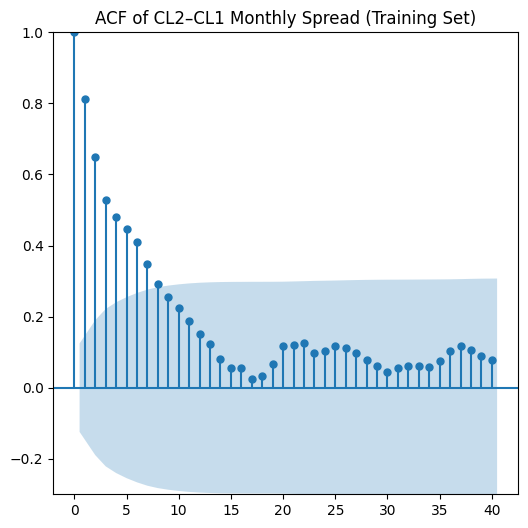

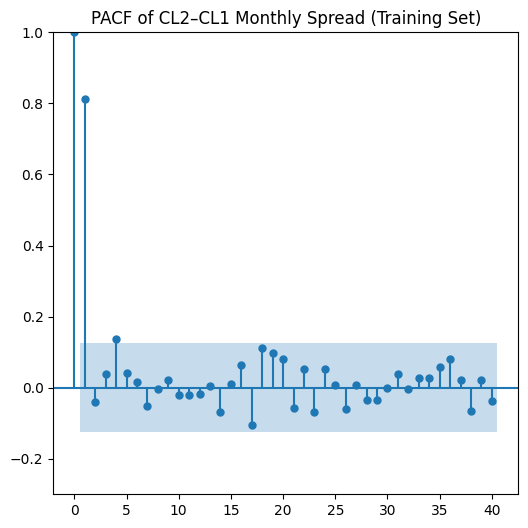

In [11]:
# ACF and PACF Plots

fig, ax = plt.subplots(figsize=(6, 6))
plot_acf(m_train["spread"], lags=40, ax=ax)
ax.set_title("ACF of CL2–CL1 Monthly Spread (Training Set)")
plt.ylim(-0.3,1)
plt.show()

fig, ax = plt.subplots(figsize=(6, 6))
plot_pacf(m_train["spread"], lags=40, ax=ax)
ax.set_title("PACF of CL2–CL1 Monthly Spread (Training Set)")
plt.ylim(-0.3,1)
plt.show()

# Auto-Arima Optimal Lag Choice

In [12]:
# Define maximum lags
max_lags = 10

# Function to return model order AND IC values
def auto_arima_lag(series, max_lags, criterion):
    model = pm.auto_arima(
        series,
        start_p=0, start_q=0,
        max_p=max_lags, max_q=max_lags,
        seasonal=False,
        stepwise=True,
        suppress_warnings=True,
        information_criterion=criterion
    )
    
    return {
        "order": model.order,
        "AIC": model.aic(),
        "BIC": model.bic(),
        "HQIC": model.hqic()
    }

# Run for each criterion
results = {
    'AIC': auto_arima_lag(m_train['spread'], max_lags, 'aic'),
    'BIC': auto_arima_lag(m_train['spread'], max_lags, 'bic'),
    'HQIC': auto_arima_lag(m_train['spread'], max_lags, 'hqic')
}

# Print results cleanly
for criterion, output in results.items():
    print(f"\nOptimised by {criterion}")
    print(f"Selected order: {output['order']}")
    print(f"AIC: {output['AIC']:.4f}")
    print(f"BIC: {output['BIC']:.4f}")
    print(f"HQIC: {output['HQIC']:.4f}")


Optimised by AIC
Selected order: (0, 1, 0)
AIC: 365.2760
BIC: 368.7854
HQIC: 366.6890

Optimised by BIC
Selected order: (0, 1, 0)
AIC: 365.2760
BIC: 368.7854
HQIC: 366.6890

Optimised by HQIC
Selected order: (0, 1, 0)
AIC: 365.2760
BIC: 368.7854
HQIC: 366.6890


In [13]:
best_order = results['BIC']['order']

print(f"Selected order: ARIMA{best_order}")

Selected order: ARIMA(0, 1, 0)


# Fitting ARIMA(0,1,0)

In [14]:
# Using optimal lags from AIC

model_arima = ARIMA(y_train, order=(0, 1, 0))   
results_arima = model_arima.fit()

print(results_arima.summary())


                               SARIMAX Results                                
Dep. Variable:                 spread   No. Observations:                  248
Model:                 ARIMA(0, 1, 0)   Log Likelihood                -181.638
Date:                Tue, 17 Feb 2026   AIC                            365.276
Time:                        00:53:31   BIC                            368.785
Sample:                             0   HQIC                           366.689
                                - 248                                         
Covariance Type:                  opg                                         
                 coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------
sigma2         0.2548      0.012     20.537      0.000       0.231       0.279
Ljung-Box (L1) (Q):                   0.81   Jarque-Bera (JB):               252.09
Prob(Q):                              0.37   Pr

<Axes: title={'center': 'ARIMA Residuals'}>

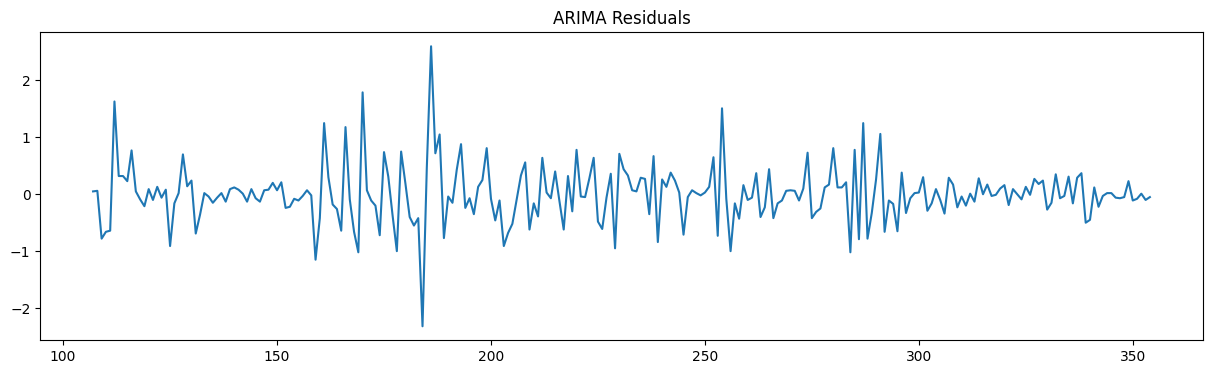

In [15]:
# Residuals plot
residuals_arima = results_arima.resid 
residuals_arima.plot(figsize=(15,4), title="ARIMA Residuals")

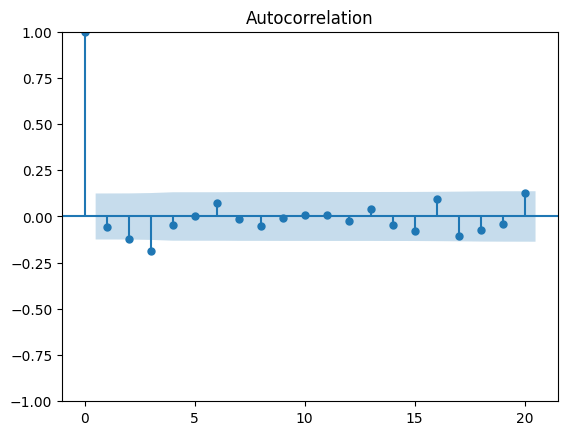

In [16]:
# Residual ACF
plot_acf(residuals_arima, lags=20);

In [17]:
# Residuals Diagnostics
# Ljung-Box test (we are looking for statistical insignifiance as we want white noise

ljung_box = acorr_ljungbox(residuals_arima, lags=[10], return_df=True)
print("Ljung box test p-value:", ljung_box["lb_pvalue"].iloc[0])

arch_test = het_arch(residuals_arima)
print("ARCH test p-value:", arch_test[1])

jb_stat, jb_pvalue, skew, kurt = jarque_bera(residuals_arima)
print("Jarque-Bera p-value:", jb_pvalue)

Ljung box test p-value: 0.08669762761202358
ARCH test p-value: 3.95891370017648e-06
Jarque-Bera p-value: 2.090233307575311e-56


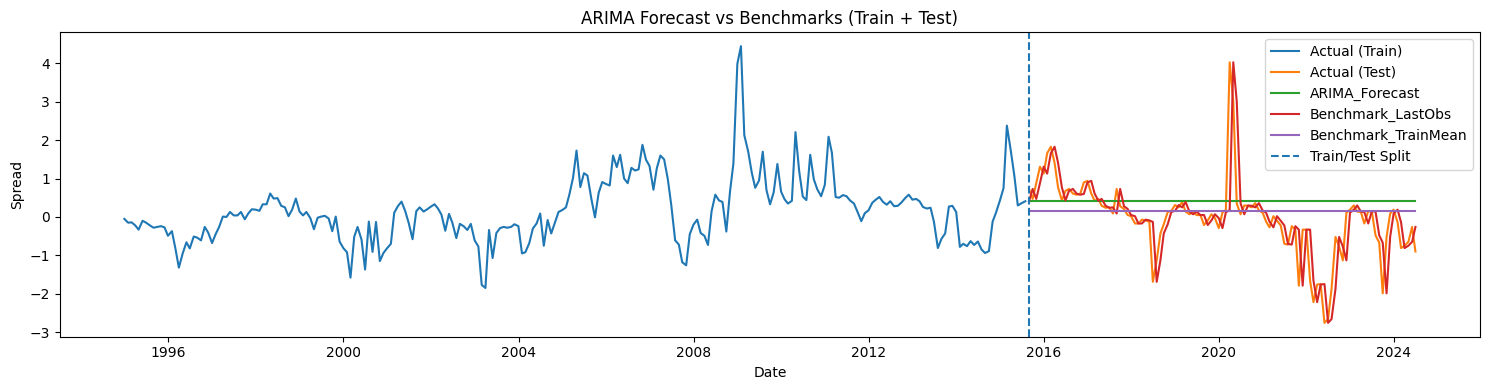

,Hitrate,MAE,RMSE,OOS_R2_vs_LastObs,OOS_R2_vs_TrainMean
Model,,,,,
Benchmark_TrainMean,0.542056,0.617372,0.966779,-1.077443,0.000000
ARIMA_Forecast,0.467290,0.723084,1.042774,-1.416884,-0.163393
Benchmark_LastObs,0.018692,0.384019,0.670753,0.000000,0.518639


In [18]:
# ----------------------------
# Build Series from m_train/m_test
# ----------------------------
train_idx = pd.to_datetime(m_train["date"])
test_idx  = pd.to_datetime(m_test["date"])

y_train = pd.Series(m_train["spread"].values, index=train_idx, name="spread")
y_test  = pd.Series(m_test["spread"].values,  index=test_idx,  name="spread")

# ----------------------------
# Benchmarks on test set
# ----------------------------
bench_last = pd.concat([y_train.iloc[-1:], y_test.iloc[:-1]])
bench_last.index = y_test.index
bench_last.name = "Benchmark_LastObs"

bench_mean = pd.Series(float(y_train.mean()), index=y_test.index, name="Benchmark_TrainMean")

# ----------------------------
# ARIMA forecast (test period)
# ----------------------------
arima_fc = results_arima.forecast(steps=len(y_test))
arima_fc.index = y_test.index
arima_fc.name = "ARIMA_Forecast"

# ----------------------------
# Metrics
# ----------------------------
def mae(y_true, y_pred) -> float:
    return float(np.mean(np.abs(y_true - y_pred)))

def rmse(y_true, y_pred) -> float:
    return float(np.sqrt(np.mean((y_true - y_pred) ** 2)))

def hitrate(y_true: pd.Series, y_pred: pd.Series, y_prev: pd.Series) -> float:
    # directional accuracy on change relative to previous actual
    actual_dir = np.sign(y_true - y_prev)
    pred_dir = np.sign(y_pred - y_prev)
    return float(np.mean(actual_dir.values == pred_dir.values))

def oos_r2(y_true: pd.Series, y_pred: pd.Series, y_bench: pd.Series) -> float:
    sse_model = float(np.sum((y_true - y_pred) ** 2))
    sse_bench = float(np.sum((y_true - y_bench) ** 2))
    return np.nan if sse_bench == 0 else 1.0 - (sse_model / sse_bench)

# ----------------------------
# Plot: Train + Test + Forecasts
# ----------------------------
plt.figure(figsize=(15, 4))

plt.plot(y_train.index, y_train.values, label="Actual (Train)")
plt.plot(y_test.index, y_test.values, label="Actual (Test)")

plt.plot(arima_fc.index, arima_fc.values, label=arima_fc.name)
plt.plot(bench_last.index, bench_last.values, label=bench_last.name)
plt.plot(bench_mean.index, bench_mean.values, label=bench_mean.name)

plt.axvline(x=y_test.index[0], linestyle="--", linewidth=1.5, label="Train/Test Split")

plt.xlabel("Date")
plt.ylabel("Spread")
plt.title("ARIMA Forecast vs Benchmarks (Train + Test)")
plt.legend()
plt.tight_layout()
plt.show()

# ----------------------------
# Performance table
# ----------------------------
rows = []

# Benchmarks
rows.append({
    "Model": "Benchmark_LastObs",
    "Hitrate": hitrate(y_test, bench_last, bench_last),
    "MAE": mae(y_test, bench_last),
    "RMSE": rmse(y_test, bench_last),
    "OOS_R2_vs_LastObs": 0.0,
    "OOS_R2_vs_TrainMean": oos_r2(y_test, bench_last, bench_mean),
})

rows.append({
    "Model": "Benchmark_TrainMean",
    "Hitrate": hitrate(y_test, bench_mean, bench_last),
    "MAE": mae(y_test, bench_mean),
    "RMSE": rmse(y_test, bench_mean),
    "OOS_R2_vs_LastObs": oos_r2(y_test, bench_mean, bench_last),
    "OOS_R2_vs_TrainMean": 0.0,
})

# ARIMA
rows.append({
    "Model": arima_fc.name,
    "Hitrate": hitrate(y_test, arima_fc, bench_last),
    "MAE": mae(y_test, arima_fc),
    "RMSE": rmse(y_test, arima_fc),
    "OOS_R2_vs_LastObs": oos_r2(y_test, arima_fc, bench_last),
    "OOS_R2_vs_TrainMean": oos_r2(y_test, arima_fc, bench_mean),
})

perf_df = pd.DataFrame(rows).set_index("Model").sort_values("Hitrate", ascending=False)
display(perf_df)

# -> Add this into after OLS ARIMAX model

/var/folders/by/g895l7l128j9y19qqn66xcxh0000gn/T/ipykernel_20367/3439107902.py:25: Pandas4Warning: Sorting by default when concatenating all DatetimeIndex is deprecated.  In the future, pandas will respect the default of `sort=False`. Specify `sort=True` or `sort=False` to silence this message. If you see this warnings when not directly calling concat, report a bug to pandas.
  exog = pd.concat([macro_i, prices_i], axis=1)


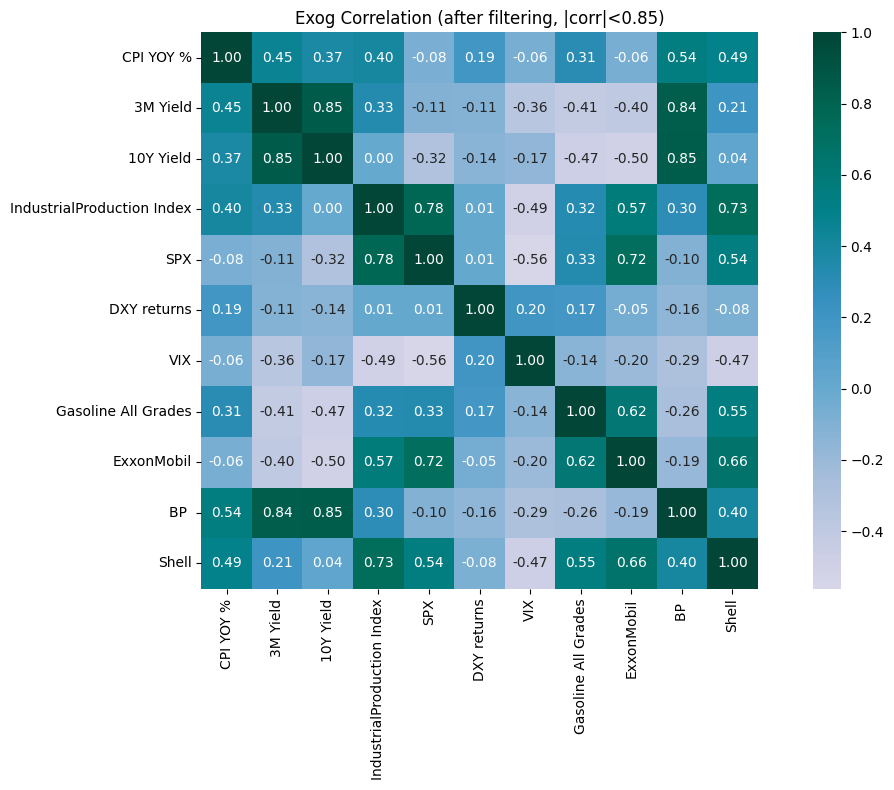

In [19]:
# Build y_train, y_test from m_train/m_test
y_train = pd.Series(
    m_train["spread"].values,
    index=pd.to_datetime(m_train["date"]),
    name="spread"
).sort_index()

y_test = pd.Series(
    m_test["spread"].values,
    index=pd.to_datetime(m_test["date"]),
    name="spread"
).sort_index()

# Build monthly exog matrix aligned to y (avoid look-ahead)
def build_exog(macro: pd.DataFrame, prices: pd.DataFrame, exog_lag: int = 1) -> pd.DataFrame:
    macro_i = macro.copy()
    prices_i = prices.copy()

    macro_i["Date"] = pd.to_datetime(macro_i["Date"])
    prices_i["Date"] = pd.to_datetime(prices_i["Date"])

    macro_i = macro_i.sort_values("Date").set_index("Date")
    prices_i = prices_i.sort_values("Date").set_index("Date")

    exog = pd.concat([macro_i, prices_i], axis=1)

    # Drop duplicated columns if any
    exog = exog.loc[:, ~exog.columns.duplicated()]

    # Lag to ensure you only use information known before trading date
    exog = exog.shift(exog_lag)

    return exog

EXOG_LAG = 1  # set to 0 only if your assignment assumes contemporaneous availability
exog_all = build_exog(macro, prices, exog_lag=EXOG_LAG)

# Align exog to train/test indices and drop missing rows (must be aligned for ARIMAX)
X_train = exog_all.reindex(y_train.index)
X_test  = exog_all.reindex(y_test.index)

# Drop rows with any missing values (ARIMAX cannot handle NaNs)
train_df = pd.concat([y_train, X_train], axis=1).dropna()
test_df  = pd.concat([y_test,  X_test],  axis=1).dropna()

y_train = train_df["spread"]
X_train = train_df.drop(columns=["spread"])

y_test  = test_df["spread"]
X_test  = test_df.drop(columns=["spread"])

# Drop highly correlated features (pairwise correlation filter)
def drop_high_corr_features(X: pd.DataFrame, threshold: float = 0.85) -> pd.DataFrame:
    Xc = X.copy()
    to_drop = set()

    while True:
        corr = Xc.corr().abs()
        np.fill_diagonal(corr.values.copy(), 0.0) 

        # instead do:
        for k in range(len(corr)):
            corr.iat[k, k] = 0.0

        max_corr = corr.max().max()
        if np.isnan(max_corr) or max_corr <= threshold:
            break

        i, j = np.where(corr.to_numpy() == max_corr)
        i, j = int(i[0]), int(j[0])
        col_i, col_j = corr.index[i], corr.columns[j]

        drop_col = col_i if corr[col_i].mean() >= corr[col_j].mean() else col_j
        to_drop.add(drop_col)
        Xc = Xc.drop(columns=[drop_col])

        if Xc.shape[1] <= 1:
            break

    return X.drop(columns=list(to_drop), errors="ignore")

CORR_THRESH = 0.85
X_train_f = drop_high_corr_features(X_train, threshold=CORR_THRESH)

# Make test set consistent
X_test_f = X_test.reindex(columns=X_train_f.columns)

# (Optional) heatmap after filtering
plt.figure(figsize=(12, 8))
sns.heatmap(X_train_f.corr(), annot=True, fmt=".2f", cmap="PuBuGn", center=0, square=True)
plt.title(f"Exog Correlation (after filtering, |corr|<{CORR_THRESH})")
plt.tight_layout()
plt.show()

In [20]:
# VIF filter for multicollinearity
def compute_vif(X: pd.DataFrame) -> pd.Series:
    X_ = X.copy()
    X_ = X_.replace([np.inf, -np.inf], np.nan).dropna(axis=1, how="any")
    if X_.shape[1] == 0:
        return pd.Series(dtype=float)
    # add constant implicitly by centering (VIF doesn't require explicit const, but helps numerically)
    Xv = X_.values
    vifs = []
    for k in range(X_.shape[1]):
        vifs.append(variance_inflation_factor(Xv, k))
    return pd.Series(vifs, index=X_.columns, name="VIF")

def drop_high_vif(X: pd.DataFrame, vif_threshold: float = 10.0) -> pd.DataFrame:
    """
    Iteratively drop the variable with the highest VIF until all VIFs <= threshold.
    """
    Xc = X.copy()
    while Xc.shape[1] > 1:
        v = compute_vif(Xc)
        if v.empty or np.nanmax(v.values) <= vif_threshold:
            break
        drop_col = v.idxmax()
        Xc = Xc.drop(columns=[drop_col])
    return Xc

VIF_THRESH = 10.0
X_train_f = drop_high_vif(X_train_f, vif_threshold=VIF_THRESH)
X_test_f = X_test_f.reindex(columns=X_train_f.columns)

# Print final exog set
print("Final exogenous variables used in ARIMAX:")
print(list(X_train_f.columns))

Final exogenous variables used in ARIMAX:
['CPI YOY %', '3M Yield', 'SPX', 'DXY returns', 'VIX']


In [21]:
"""
# Fix the "no frequency information" warning
# (do this once after y_train/y_test and X_train_f/X_test_f exist)
# Choose ONE: "M" (month-end) or "BM" (business month-end)
"""

FREQ = "ME"   # try "BM" if your dates are business month-end

# Force frequency on y (and align to X)
y_train = y_train.asfreq(FREQ)
y_test  = y_test.asfreq(FREQ)

X_train_f = X_train_f.asfreq(FREQ)
X_test_f  = X_test_f.asfreq(FREQ)

# Drop any rows that became missing due to asfreq alignment (safety)
train_df = pd.concat([y_train, X_train_f], axis=1).dropna()
test_df  = pd.concat([y_test,  X_test_f],  axis=1).dropna()

y_train = train_df["spread"]
X_train_f = train_df.drop(columns=["spread"])

y_test = test_df["spread"]
X_test_f = test_df.drop(columns=["spread"])

print("Post-freq shapes:", y_train.shape, X_train_f.shape, y_test.shape, X_test_f.shape)

y_train.index = y_train.index.to_period("M").to_timestamp("M")
y_test.index  = y_test.index.to_period("M").to_timestamp("M")

Post-freq shapes: (54,) (54, 5) (49,) (49, 5)


In [22]:
# ARIMAX parameter search (AIC/BIC) using method="statespace"
# (now that single-fit works)
import warnings
warnings.filterwarnings('ignore')
import numpy as np
import pandas as pd
from statsmodels.tsa.arima.model import ARIMA

def arimax_grid_search(y, X, p_max=4, d_max=1, q_max=4, criterion="aic",
                       skip_nonconverged=True,
                       enforce_stationarity=False,
                       enforce_invertibility=False):
    rows, fails = [], []

    for p in range(p_max + 1):
        for d in range(d_max + 1):
            for q in range(q_max + 1):
                if (p, d, q) == (0, 0, 0):
                    continue
                try:
                    res = ARIMA(
                        y, order=(p, d, q), exog=X,
                        enforce_stationarity=enforce_stationarity,
                        enforce_invertibility=enforce_invertibility
                    ).fit(method="statespace")

                    converged = bool(getattr(res, "mle_retvals", {}).get("converged", True))
                    score = float(getattr(res, criterion))

                    if skip_nonconverged and (not converged):
                        continue

                    rows.append({
                        "p": p, "d": d, "q": q,
                        "order": (p, d, q),
                        criterion: score,
                        "converged": converged
                    })

                except Exception as e:
                    fails.append({"order": (p, d, q), "error": str(e)})

    grid = pd.DataFrame(rows)
    fail_df = pd.DataFrame(fails)

    print("Successful fits kept:", len(grid))
    print("Failed fits:", len(fail_df))

    if grid.empty:
        return {"order": None, "score": np.inf}, grid, fail_df

    grid = grid.sort_values(criterion).reset_index(drop=True)
    best = {
        "order": tuple(grid.loc[0, "order"]),
        "score": float(grid.loc[0, criterion]),
        "converged": bool(grid.loc[0, "converged"])
    }
    return best, grid, fail_df

best_aic, grid_aic, fails_aic = arimax_grid_search(
    y_train, X_train_f,
    p_max=2, d_max=1, q_max=2,
    criterion="aic",
    skip_nonconverged=True
)

best_bic, grid_bic, fails_bic = arimax_grid_search(
    y_train, X_train_f,
    p_max=2, d_max=1, q_max=2,
    criterion="bic",
    skip_nonconverged=True
)

print("Best ARIMAX by AIC:", best_aic)
print("Best ARIMAX by BIC:", best_bic)

ARIMAX_ORDER = best_aic["order"]
print("Selected ARIMAX_ORDER:", ARIMAX_ORDER)

Successful fits kept: 10
Failed fits: 0
Successful fits kept: 10
Failed fits: 0
Best ARIMAX by AIC: {'order': (2, 0, 0), 'score': 81.97345948626852, 'converged': True}
Best ARIMAX by BIC: {'order': (2, 0, 0), 'score': 99.53465295350136, 'converged': True}
Selected ARIMAX_ORDER: (2, 0, 0)


In [23]:
print("y_train:", len(y_train))
print("X_train_f:", len(X_train_f))

print("y_test:", len(y_test))
print("X_test_f:", len(X_test_f))

y_train: 54
X_train_f: 54
y_test: 49
X_test_f: 49


In [24]:
grid_bic

,p,d,q,order,bic,converged
0,2,0,0,"(2, 0, 0)",99.534653,True
1,0,0,2,"(0, 0, 2)",103.077846,True
2,1,0,1,"(1, 0, 1)",104.042750,True
3,1,0,0,"(1, 0, 0)",104.426542,True
4,1,1,1,"(1, 1, 1)",104.612614,True
5,0,1,0,"(0, 1, 0)",106.744579,True
6,1,0,2,"(1, 0, 2)",107.111874,True
7,2,1,0,"(2, 1, 0)",107.708796,True
8,0,1,1,"(0, 1, 1)",108.985211,True
9,1,1,0,"(1, 1, 0)",110.521128,True


In [25]:
# Fit final ARIMAX, print summary
model_arimax = ARIMA(y_train, order=ARIMAX_ORDER, exog=X_train_f)
results_arimax = model_arimax.fit()

print(results_arimax.summary())

                               SARIMAX Results                                
Dep. Variable:                 spread   No. Observations:                   54
Model:                 ARIMA(2, 0, 0)   Log Likelihood                 -34.370
Date:                Tue, 17 Feb 2026   AIC                             86.740
Time:                        00:53:32   BIC                            104.641
Sample:                             0   HQIC                            93.644
                                 - 54                                         
Covariance Type:                  opg                                         
                  coef    std err          z      P>|z|      [0.025      0.975]
-------------------------------------------------------------------------------
const           4.3454      0.702      6.192      0.000       2.970       5.721
CPI YOY %      -0.1141      0.065     -1.749      0.080      -0.242       0.014
3M Yield        0.0501      0.062      0.803    

,Test,Statistic,p-value
0,Ljung-Box (lag 10),5.616485,0.846390
1,ARCH LM (lag 10),5.071466,0.886353
2,Jarque-Bera,4.831945,0.089280


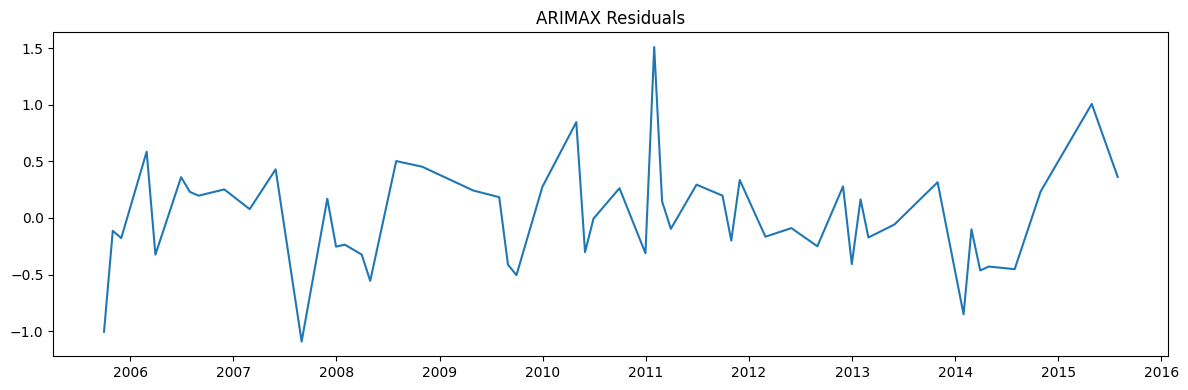

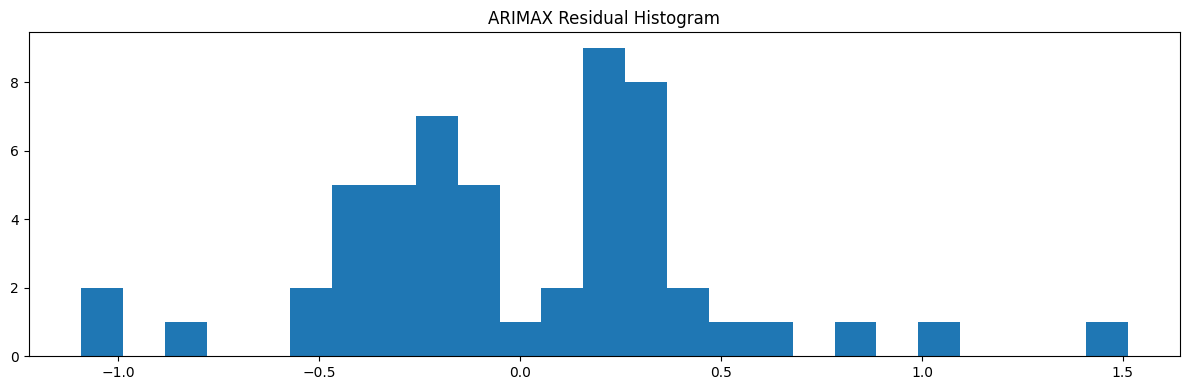

In [26]:
# Diagnostics (residual tests)
residuals_arimax = results_arimax.resid.dropna()

# Ljung-Box (autocorrelation)
lb = acorr_ljungbox(residuals_arimax, lags=[10], return_df=True)

# ARCH (conditional heteroskedasticity)
arch_stat, arch_p, _, _ = het_arch(residuals_arimax, nlags=10)

# Jarque-Bera (normality)
jb_stat, jb_p, skew, kurt = jarque_bera(residuals_arimax)

diag_tbl = pd.DataFrame({
    "Test": ["Ljung-Box (lag 10)", "ARCH LM (lag 10)", "Jarque-Bera"],
    "Statistic": [float(lb["lb_stat"].iloc[0]), float(arch_stat), float(jb_stat)],
    "p-value":   [float(lb["lb_pvalue"].iloc[0]), float(arch_p), float(jb_p)]
})

display(diag_tbl)

# Residual plots
plt.figure(figsize=(12, 4))
plt.plot(residuals_arimax.index, residuals_arimax.values)
plt.title("ARIMAX Residuals")
plt.tight_layout()
plt.show()

plt.figure(figsize=(12, 4))
plt.hist(residuals_arimax.values, bins=25)
plt.title("ARIMAX Residual Histogram")
plt.tight_layout()
plt.show()

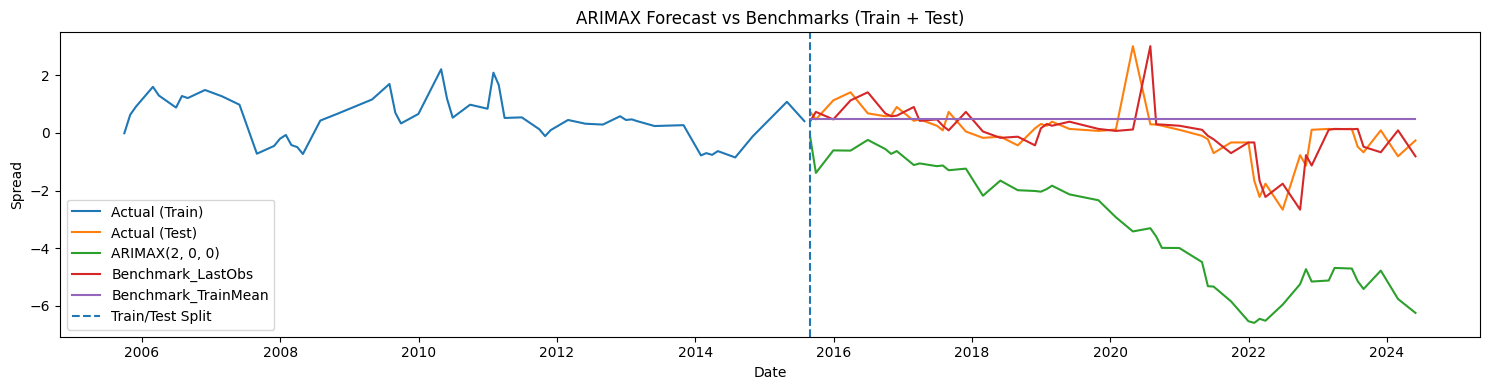

,Hitrate,MAE,RMSE,OOS_R2_vs_LastObs,OOS_R2_vs_TrainMean
Model,,,,,
"ARIMAX(2, 0, 0)",0.551020,3.282824,3.666200,-21.176689,-12.048466
Benchmark_TrainMean,0.489796,0.708893,1.014931,-0.699563,0.000000
Benchmark_LastObs,0.020408,0.480612,0.778516,0.000000,0.411613


In [27]:
# Forecast and compare to benchmarks
# Benchmarks (test period)
bench_last = pd.concat([y_train.iloc[-1:], y_test.iloc[:-1]])
bench_last.index = y_test.index
bench_last.name = "Benchmark_LastObs"

bench_mean = pd.Series(float(y_train.mean()), index=y_test.index, name="Benchmark_TrainMean")

# ARIMAX forecast (static)
arimax_fc = results_arimax.forecast(steps=len(y_test), exog=X_test_f)
arimax_fc.index = y_test.index
arimax_fc.name = f"ARIMAX{ARIMAX_ORDER}"

# Plot: train + test + forecasts
plt.figure(figsize=(15, 4))
plt.plot(y_train.index, y_train.values, label="Actual (Train)")
plt.plot(y_test.index, y_test.values, label="Actual (Test)")
plt.plot(arimax_fc.index, arimax_fc.values, label=arimax_fc.name)
plt.plot(bench_last.index, bench_last.values, label=bench_last.name)
plt.plot(bench_mean.index, bench_mean.values, label=bench_mean.name)
plt.axvline(x=y_test.index[0], linestyle="--", linewidth=1.5, label="Train/Test Split")
plt.xlabel("Date")
plt.ylabel("Spread")
plt.title("ARIMAX Forecast vs Benchmarks (Train + Test)")
plt.legend()
plt.tight_layout()
plt.show()

# Performance table (hitrate + MAE/RMSE + OOS R2)
def mae(y_true, y_pred) -> float:
    return float(np.mean(np.abs(y_true - y_pred)))

def rmse(y_true, y_pred) -> float:
    return float(np.sqrt(np.mean((y_true - y_pred) ** 2)))

def hitrate(y_true: pd.Series, y_pred: pd.Series, y_prev: pd.Series) -> float:
    actual_dir = np.sign(y_true - y_prev)
    pred_dir = np.sign(y_pred - y_prev)
    return float(np.mean(actual_dir.values == pred_dir.values))

def oos_r2(y_true: pd.Series, y_pred: pd.Series, y_bench: pd.Series) -> float:
    sse_model = float(np.sum((y_true - y_pred) ** 2))
    sse_bench = float(np.sum((y_true - y_bench) ** 2))
    return np.nan if sse_bench == 0 else 1.0 - (sse_model / sse_bench)

rows = []

# Benchmarks
rows.append({
    "Model": "Benchmark_LastObs",
    "Hitrate": hitrate(y_test, bench_last, bench_last),
    "MAE": mae(y_test, bench_last),
    "RMSE": rmse(y_test, bench_last),
    "OOS_R2_vs_LastObs": 0.0,
    "OOS_R2_vs_TrainMean": oos_r2(y_test, bench_last, bench_mean),
})

rows.append({
    "Model": "Benchmark_TrainMean",
    "Hitrate": hitrate(y_test, bench_mean, bench_last),
    "MAE": mae(y_test, bench_mean),
    "RMSE": rmse(y_test, bench_mean),
    "OOS_R2_vs_LastObs": oos_r2(y_test, bench_mean, bench_last),
    "OOS_R2_vs_TrainMean": 0.0,
})

# ARIMAX
rows.append({
    "Model": arimax_fc.name,
    "Hitrate": hitrate(y_test, arimax_fc, bench_last),
    "MAE": mae(y_test, arimax_fc),
    "RMSE": rmse(y_test, arimax_fc),
    "OOS_R2_vs_LastObs": oos_r2(y_test, arimax_fc, bench_last),
    "OOS_R2_vs_TrainMean": oos_r2(y_test, arimax_fc, bench_mean),
})

perf_df = pd.DataFrame(rows).set_index("Model").sort_values("Hitrate", ascending=False)
display(perf_df)

# OLS Regression

In [28]:
# Build y_train / y_test from m_train / m_test
y_train = pd.Series(
    m_train["spread"].values,
    index=pd.to_datetime(m_train["date"]),
    name="spread"
).sort_index()

y_test = pd.Series(
    m_test["spread"].values,
    index=pd.to_datetime(m_test["date"]),
    name="spread"
).sort_index()

# Ensure indices align with X_train_f / X_test_f (which were built from the same dates)
# If you dropped NA rows earlier in ARIMAX prep, align here too:
train_df = pd.concat([y_train, X_train_f], axis=1).dropna()
test_df  = pd.concat([y_test,  X_test_f],  axis=1).dropna()

y_train = train_df["spread"]
X_train = train_df.drop(columns=["spread"])

y_test  = test_df["spread"]
X_test  = test_df.drop(columns=["spread"])

# Fit OLS + print summary
X_train_const = sm.add_constant(X_train, has_constant="add")
ols_res = sm.OLS(y_train, X_train_const).fit()

print(ols_res.summary())

                            OLS Regression Results                            
Dep. Variable:                 spread   R-squared:                       0.469
Model:                            OLS   Adj. R-squared:                  0.414
Method:                 Least Squares   F-statistic:                     8.480
Date:                Tue, 17 Feb 2026   Prob (F-statistic):           8.27e-06
Time:                        00:53:32   Log-Likelihood:                -44.467
No. Observations:                  54   AIC:                             100.9
Df Residuals:                      48   BIC:                             112.9
Df Model:                           5                                         
Covariance Type:            nonrobust                                         
                  coef    std err          t      P>|t|      [0.025      0.975]
-------------------------------------------------------------------------------
const           4.3425      0.758      5.726      

,Test,Statistic,p-value
0,Ljung-Box (lag 10),5.616485,0.846390
1,ARCH LM (lag 10),5.071466,0.886353
2,Jarque-Bera,2.892462,0.235456


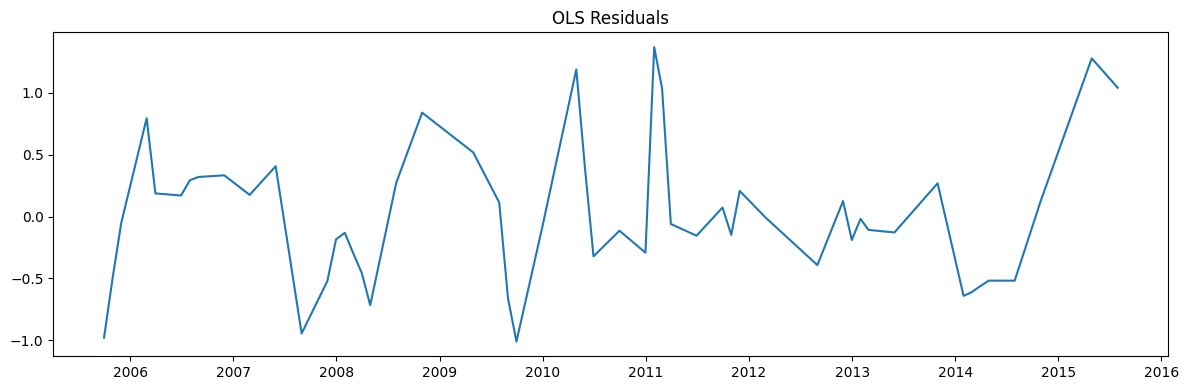

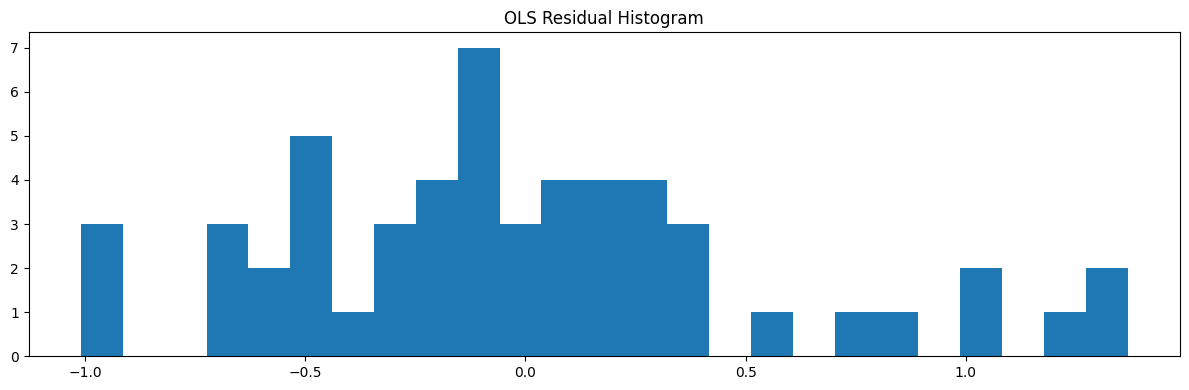

In [29]:
# Diagnostics
residuals_ols = ols_res.resid

# Normality
jb_stat, jb_p, skew, kurt = jarque_bera(residuals_ols)

# Heteroskedasticity
bp_stat, bp_p, _, _ = het_breuschpagan(residuals_ols, X_train_const)

# Autocorrelation
dw = durbin_watson(residuals_ols)

diag_tbl = pd.DataFrame({
    "Test": ["Ljung-Box (lag 10)", "ARCH LM (lag 10)", "Jarque-Bera"],
    "Statistic": [float(lb["lb_stat"].iloc[0]), float(arch_stat), float(jb_stat)],
    "p-value":   [float(lb["lb_pvalue"].iloc[0]), float(arch_p), float(jb_p)]
})
display(diag_tbl)

plt.figure(figsize=(12, 4))
plt.plot(residuals_ols.index, residuals_ols.values)
plt.title("OLS Residuals")
plt.tight_layout()
plt.show()

plt.figure(figsize=(12, 4))
plt.hist(residuals_ols.values, bins=25)
plt.title("OLS Residual Histogram")
plt.tight_layout()
plt.show()


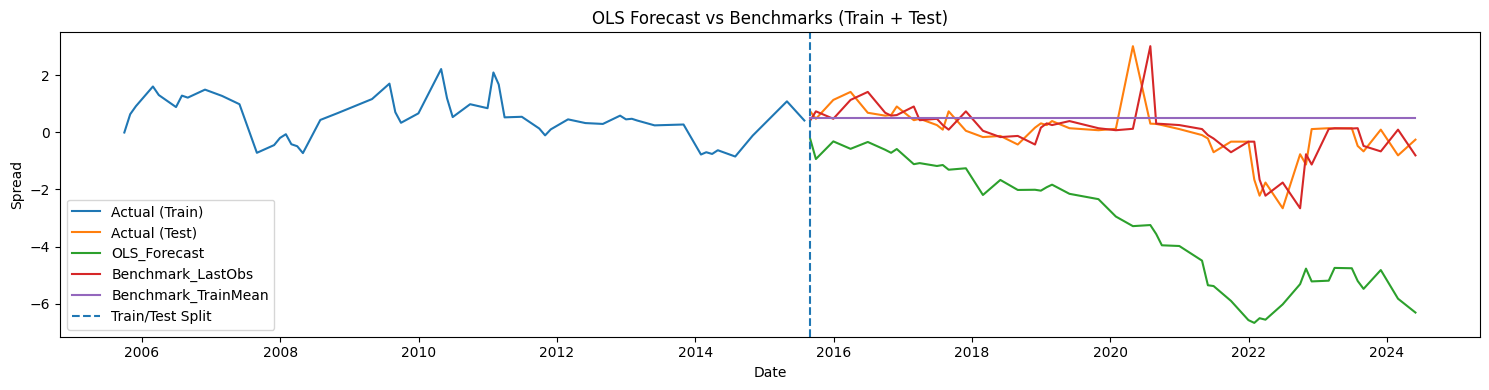

,Hitrate,MAE,RMSE,OOS_R2_vs_LastObs,OOS_R2_vs_TrainMean
Model,,,,,
OLS_Regression,0.551020,3.293474,3.685468,-21.410410,-12.185985
Benchmark_TrainMean,0.489796,0.708893,1.014931,-0.699563,0.000000
Benchmark_LastObs,0.020408,0.480612,0.778516,0.000000,0.411613


In [30]:
# Forecast test set
X_test_const = sm.add_constant(X_test, has_constant="add")
ols_fc = ols_res.predict(X_test_const)
ols_fc = pd.Series(ols_fc.values, index=y_test.index, name="OLS_Forecast")

# Benchmarks (test set)
bench_last = pd.concat([y_train.iloc[-1:], y_test.iloc[:-1]])
bench_last.index = y_test.index
bench_last.name = "Benchmark_LastObs"

bench_mean = pd.Series(float(y_train.mean()), index=y_test.index, name="Benchmark_TrainMean")

# Plot: Train + Test + OLS vs benchmarks
plt.figure(figsize=(15, 4))

plt.plot(y_train.index, y_train.values, label="Actual (Train)")
plt.plot(y_test.index, y_test.values, label="Actual (Test)")

plt.plot(ols_fc.index, ols_fc.values, label=ols_fc.name)
plt.plot(bench_last.index, bench_last.values, label=bench_last.name)
plt.plot(bench_mean.index, bench_mean.values, label=bench_mean.name)

plt.axvline(x=y_test.index[0], linestyle="--", linewidth=1.5, label="Train/Test Split")

plt.xlabel("Date")
plt.ylabel("Spread")
plt.title("OLS Forecast vs Benchmarks (Train + Test)")
plt.legend()
plt.tight_layout()
plt.show()

# Performance table
def mae(y_true, y_pred) -> float:
    return float(np.mean(np.abs(y_true - y_pred)))

def rmse(y_true, y_pred) -> float:
    return float(np.sqrt(np.mean((y_true - y_pred) ** 2)))

def hitrate(y_true: pd.Series, y_pred: pd.Series, y_prev: pd.Series) -> float:
    actual_dir = np.sign(y_true - y_prev)
    pred_dir = np.sign(y_pred - y_prev)
    return float(np.mean(actual_dir.values == pred_dir.values))

def oos_r2(y_true: pd.Series, y_pred: pd.Series, y_bench: pd.Series) -> float:
    sse_model = float(np.sum((y_true - y_pred) ** 2))
    sse_bench = float(np.sum((y_true - y_bench) ** 2))
    return np.nan if sse_bench == 0 else 1.0 - (sse_model / sse_bench)

rows = []

rows.append({
    "Model": "Benchmark_LastObs",
    "Hitrate": hitrate(y_test, bench_last, bench_last),
    "MAE": mae(y_test, bench_last),
    "RMSE": rmse(y_test, bench_last),
    "OOS_R2_vs_LastObs": 0.0,
    "OOS_R2_vs_TrainMean": oos_r2(y_test, bench_last, bench_mean),
})

rows.append({
    "Model": "Benchmark_TrainMean",
    "Hitrate": hitrate(y_test, bench_mean, bench_last),
    "MAE": mae(y_test, bench_mean),
    "RMSE": rmse(y_test, bench_mean),
    "OOS_R2_vs_LastObs": oos_r2(y_test, bench_mean, bench_last),
    "OOS_R2_vs_TrainMean": 0.0,
})

rows.append({
    "Model": "OLS_Regression",
    "Hitrate": hitrate(y_test, ols_fc, bench_last),
    "MAE": mae(y_test, ols_fc),
    "RMSE": rmse(y_test, ols_fc),
    "OOS_R2_vs_LastObs": oos_r2(y_test, ols_fc, bench_last),
    "OOS_R2_vs_TrainMean": oos_r2(y_test, ols_fc, bench_mean),
})

perf_df = pd.DataFrame(rows).set_index("Model").sort_values("Hitrate", ascending=False)
display(perf_df)


In [31]:
# Conducting out-of-sample forecasts
# SETTINGS
TARGET_COL = "spread"
SPLIT_RATIO = 0.7
HORIZON = 1
STEP = 1
ARIMA_ORDER = (0, 1, 0)      # Baseline ARIMA (random walk)
ARIMAX_ORDER = (2, 1, 1)

# Recommended rolling window for MONTHLY oil: 36 (3 years)
# 3 months is generally too short for stable ARIMA/ARIMAX estimation.
ROLLING_WINDOW = 36

# If you *must* present the 3-month idea in text, keep it as a "conceptual"
# framing but use 36 months in estimation for econometric stability.

# Build ONE aligned df_all (target + final exog columns)
y_full = pd.Series(
    m[TARGET_COL].values,
    index=pd.to_datetime(m["date"]),
    name=TARGET_COL
).sort_index()

# Keep only exog columns that survived your ARIMAX filtering
final_exog_cols = list(X_train_f.columns)

X_full = exog_all[final_exog_cols].reindex(y_full.index)

df_all = pd.concat([y_full, X_full], axis=1).dropna().sort_index()

# Define split based on aligned df_all
n = len(df_all)
split_idx = int(SPLIT_RATIO * n)

train_df_static = df_all.iloc[:split_idx]
test_df_static  = df_all.iloc[split_idx:]

y_train_static = train_df_static[TARGET_COL]
y_test_static  = test_df_static[TARGET_COL]

X_train_static = train_df_static.drop(columns=[TARGET_COL])
X_test_static  = test_df_static.drop(columns=[TARGET_COL])

# Benchmarks (for the test region in df_all)
def bench_last_obs(y_all: pd.Series, split_idx: int) -> pd.Series:
    y_test = y_all.iloc[split_idx:]
    y_prev = pd.concat([y_all.iloc[split_idx-1:split_idx], y_test.iloc[:-1]])
    y_prev.index = y_test.index
    return y_prev.rename("Benchmark_LastObs")

def bench_train_mean(y_all: pd.Series, split_idx: int) -> pd.Series:
    m_ = float(y_all.iloc[:split_idx].mean())
    y_test = y_all.iloc[split_idx:]
    return pd.Series(m_, index=y_test.index, name="Benchmark_TrainMean")

bench_last_static = bench_last_obs(df_all[TARGET_COL], split_idx)
bench_mean_static = bench_train_mean(df_all[TARGET_COL], split_idx)

# Metrics
def mae(y_true, y_pred) -> float:
    return float(np.mean(np.abs(y_true - y_pred)))

def rmse(y_true, y_pred) -> float:
    return float(np.sqrt(np.mean((y_true - y_pred) ** 2)))

def hitrate(y_true: pd.Series, y_pred: pd.Series, y_prev: pd.Series) -> float:
    actual_dir = np.sign(y_true - y_prev)
    pred_dir = np.sign(y_pred - y_prev)
    return float(np.mean(actual_dir.values == pred_dir.values))

def oos_r2(y_true: pd.Series, y_pred: pd.Series, y_bench: pd.Series) -> float:
    sse_model = float(np.sum((y_true - y_pred) ** 2))
    sse_bench = float(np.sum((y_true - y_bench) ** 2))
    return np.nan if sse_bench == 0 else 1.0 - (sse_model / sse_bench)

def perf_row(name: str, y_true: pd.Series, y_pred: pd.Series,
             bench_last: pd.Series, bench_mean: pd.Series) -> dict:
    # Align everything (important for dynamic which may have fewer points)
    idx = y_true.index.intersection(y_pred.index)
    yt = y_true.reindex(idx)
    yp = y_pred.reindex(idx)
    bl = bench_last.reindex(idx)
    bm = bench_mean.reindex(idx)

    return {
        "Model": name,
        "N": len(idx),
        "Hitrate": hitrate(yt, yp, bl),
        "MAE": mae(yt, yp),
        "RMSE": rmse(yt, yp),
        "OOS_R2_vs_LastObs": oos_r2(yt, yp, bl),
        "OOS_R2_vs_TrainMean": oos_r2(yt, yp, bm),
    }

# ----------------------------
# 4) STATIC forecasts (using already-fitted objects)
# ----------------------------
# ARIMA static
arima_static_fc = results_arima.forecast(steps=len(y_test_static))
arima_static_fc.index = y_test_static.index
arima_static_fc.name = "ARIMA_Static"

# ARIMAX static (shape-safe because we built X_test_static from df_all)
arimax_static_fc = results_arimax.forecast(steps=len(y_test_static), exog=X_test_static)
arimax_static_fc.index = y_test_static.index
arimax_static_fc.name = "ARIMAX_Static"

# OLS static (shape-safe)
ols_static_fc = ols_res.predict(sm.add_constant(X_test_static, has_constant="add"))
ols_static_fc = pd.Series(ols_static_fc.values, index=y_test_static.index, name="OLS_Static")

# DYNAMIC rolling-window one-step-ahead forecasts
def rolling_dynamic_arima(df: pd.DataFrame, target_col: str,
                          order: tuple, train_window: int,
                          split_idx: int, horizon: int = 1, step: int = 1) -> pd.Series:
    y = df[target_col]
    preds, dates = [], []

    last_start = len(df) - horizon
    for end_train in range(train_window, last_start, step):
        forecast_index = end_train + horizon - 1
        if forecast_index < split_idx:
            continue

        y_train = y.iloc[end_train-train_window:end_train]

        try:
            res = ARIMA(y_train, order=order).fit()
            fc = res.forecast(steps=horizon).iloc[-1]
        except Exception:
            fc = np.nan

        preds.append(fc)
        dates.append(df.index[forecast_index])

    return pd.Series(preds, index=pd.to_datetime(dates), name="ARIMA_Dynamic").dropna()

def rolling_dynamic_arimax(df: pd.DataFrame, target_col: str, feature_cols: list[str],
                           order: tuple, train_window: int,
                           split_idx: int, horizon: int = 1, step: int = 1) -> pd.Series:
    preds, dates = [], []
    last_start = len(df) - horizon

    for end_train in range(train_window, last_start, step):
        forecast_index = end_train + horizon - 1
        if forecast_index < split_idx:
            continue

        train = df.iloc[end_train-train_window:end_train]
        test  = df.iloc[forecast_index:forecast_index+1]

        y_train = train[target_col]
        X_train = train[feature_cols]
        X_test  = test[feature_cols]

        try:
            res = ARIMA(y_train, order=order, exog=X_train).fit()
            fc = res.forecast(steps=horizon, exog=X_test).iloc[-1]
        except Exception:
            fc = np.nan

        preds.append(fc)
        dates.append(test.index[0])

    return pd.Series(preds, index=pd.to_datetime(dates), name="ARIMAX_Dynamic").dropna()

def rolling_dynamic_ols(df: pd.DataFrame, target_col: str, feature_cols: list[str],
                        train_window: int, split_idx: int,
                        horizon: int = 1, step: int = 1) -> pd.Series:
    preds, dates = [], []
    last_start = len(df) - horizon

    for end_train in range(train_window, last_start, step):
        forecast_index = end_train + horizon - 1
        if forecast_index < split_idx:
            continue

        train = df.iloc[end_train-train_window:end_train]
        test  = df.iloc[forecast_index:forecast_index+1]

        y_train = train[target_col]
        X_train = sm.add_constant(train[feature_cols], has_constant="add")
        X_test  = sm.add_constant(test[feature_cols], has_constant="add")

        try:
            res = sm.OLS(y_train, X_train).fit()
            fc = float(res.predict(X_test).iloc[-1])
        except Exception:
            fc = np.nan

        preds.append(fc)
        dates.append(test.index[0])

    return pd.Series(preds, index=pd.to_datetime(dates), name="OLS_Dynamic").dropna()

feature_cols = final_exog_cols

arima_dyn_fc  = rolling_dynamic_arima(df_all, TARGET_COL, ARIMA_ORDER, ROLLING_WINDOW, split_idx, HORIZON, STEP)
arimax_dyn_fc = rolling_dynamic_arimax(df_all, TARGET_COL, feature_cols, ARIMAX_ORDER, ROLLING_WINDOW, split_idx, HORIZON, STEP)
ols_dyn_fc    = rolling_dynamic_ols(df_all, TARGET_COL, feature_cols, ROLLING_WINDOW, split_idx, HORIZON, STEP)

# For dynamic evaluation, align y_true and benchmarks to the dynamic index
y_test_dyn = df_all[TARGET_COL].iloc[split_idx:].reindex(arima_dyn_fc.index)  # same region, reindexed

bench_last_dyn = bench_last_static.reindex(y_test_dyn.index)
bench_mean_dyn = bench_mean_static.reindex(y_test_dyn.index)

# PERFORMANCE TABLE: each model static vs dynamic
rows = []
rows.append(perf_row("ARIMA_Static",  y_test_static, arima_static_fc,  bench_last_static, bench_mean_static))
rows.append(perf_row("ARIMA_Dynamic", y_test_dyn,    arima_dyn_fc,     bench_last_dyn,   bench_mean_dyn))

rows.append(perf_row("ARIMAX_Static",  y_test_static, arimax_static_fc, bench_last_static, bench_mean_static))
rows.append(perf_row("ARIMAX_Dynamic", y_test_dyn,    arimax_dyn_fc,    bench_last_dyn,   bench_mean_dyn))

rows.append(perf_row("OLS_Static",  y_test_static, ols_static_fc,  bench_last_static, bench_mean_static))
rows.append(perf_row("OLS_Dynamic", y_test_dyn,    ols_dyn_fc,     bench_last_dyn,   bench_mean_dyn))

perf_df = pd.DataFrame(rows).set_index("Model").sort_values(["Hitrate", "OOS_R2_vs_LastObs"], ascending=False)
display(perf_df)

,N,Hitrate,MAE,RMSE,OOS_R2_vs_LastObs,OOS_R2_vs_TrainMean
Model,,,,,,
ARIMAX_Static,107,0.532710,3.202344,3.615880,-28.060494,-12.983721
OLS_Static,107,0.532710,3.216994,3.637531,-28.409552,-13.151686
OLS_Dynamic,106,0.500000,0.681465,0.960955,-1.050755,0.010370
ARIMAX_Dynamic,106,0.471698,0.593268,0.885224,-0.740262,0.160204
ARIMA_Static,107,0.467290,0.723084,1.042774,-1.416884,-0.162989
ARIMA_Dynamic,106,0.122642,0.381604,0.671036,0.000000,0.517432


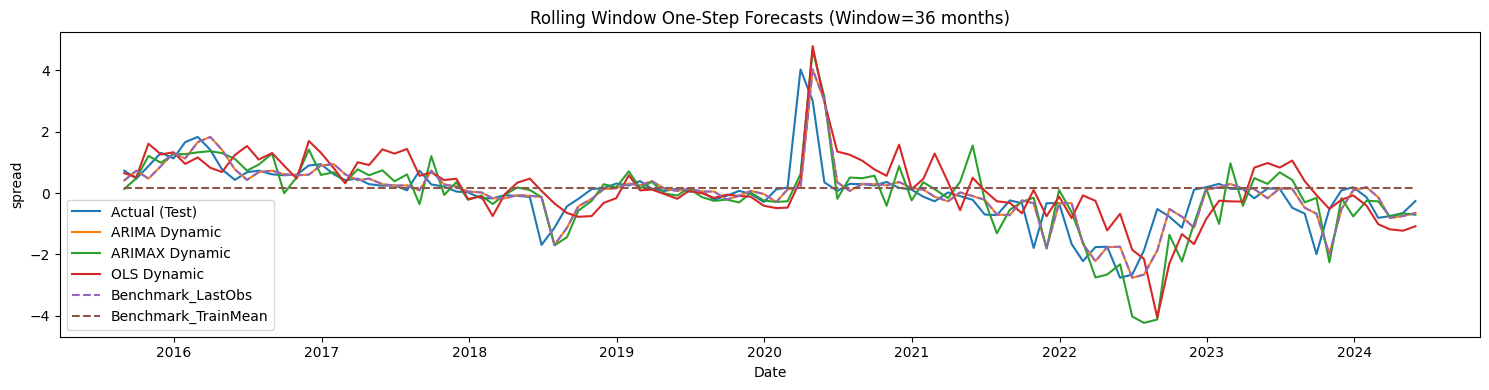

In [32]:
# Dynamic forecasts vs benchmarks (test region only)
def plot_dynamic(y_test: pd.Series, preds: dict, bench_last: pd.Series, bench_mean: pd.Series, title: str):
    plt.figure(figsize=(15, 4))
    plt.plot(y_test.index, y_test.values, label="Actual (Test)")

    for name, s in preds.items():
        s = s.reindex(y_test.index)
        plt.plot(s.index, s.values, label=name)

    plt.plot(bench_last.index, bench_last.values, linestyle="--", label=bench_last.name)
    plt.plot(bench_mean.index, bench_mean.values, linestyle="--", label=bench_mean.name)

    plt.title(title)
    plt.xlabel("Date")
    plt.ylabel(TARGET_COL)
    plt.legend()
    plt.tight_layout()
    plt.show()

# Build a common test index for plotting (intersection so lines line up)
common_idx = y_test_static.index.intersection(arima_dyn_fc.index).intersection(arimax_dyn_fc.index).intersection(ols_dyn_fc.index)
y_plot = y_test_static.reindex(common_idx)

plot_dynamic(
    y_plot,
    preds={
        "ARIMA Dynamic": arima_dyn_fc,
        "ARIMAX Dynamic": arimax_dyn_fc,
        "OLS Dynamic": ols_dyn_fc
    },
    bench_last=bench_last_static.reindex(common_idx),
    bench_mean=bench_mean_static.reindex(common_idx),
    title=f"Rolling Window One-Step Forecasts (Window={ROLLING_WINDOW} months)")

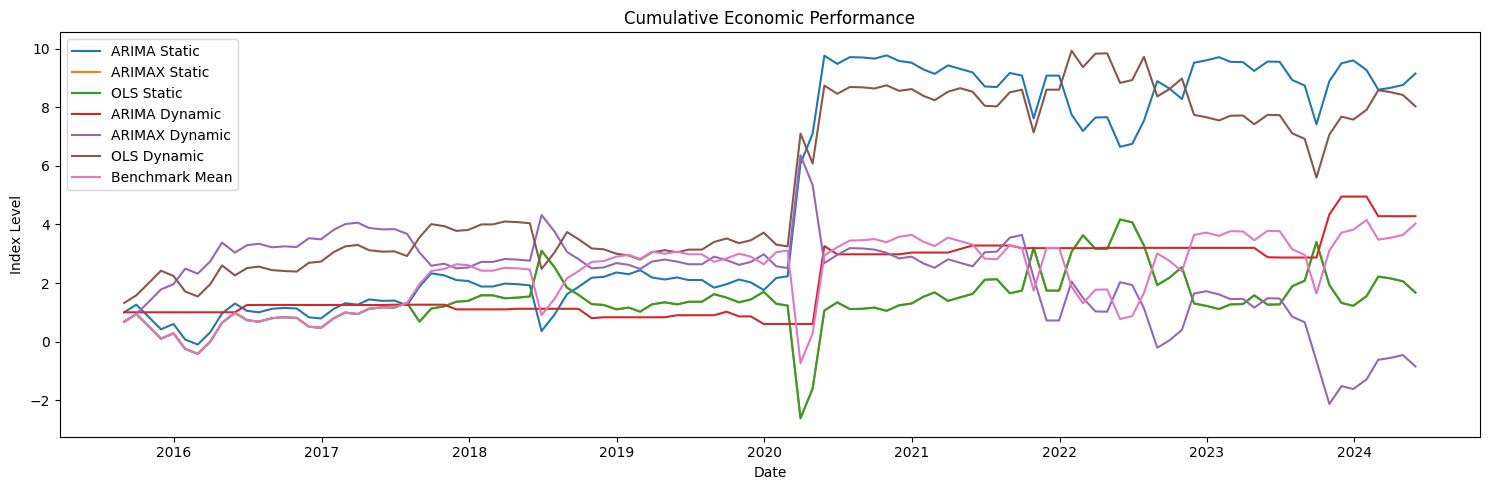

In [33]:
"""
CUMULATIVE ECONOMIC PERFORMANCE PLOTS
(turn forecasts into a simple trading rule and plot equity curves)

Assumes you already have (indexed by the SAME datetime index):
  - y_test_static              : pd.Series (actual spread in test)
  - bench_last_static, bench_mean_static : pd.Series (benchmarks on test)
  - arima_static_fc, arimax_static_fc, ols_static_fc : pd.Series (static forecasts)
  - arima_dyn_fc, arimax_dyn_fc, ols_dyn_fc           : pd.Series (dynamic forecasts)
"""

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

# ----------------------------
# 1) ALIGN EVERYTHING ON A COMMON INDEX
# ----------------------------
def common_index(series_list):
    idx = None
    for s in series_list:
        if s is None:
            continue
        idx = s.index if idx is None else idx.intersection(s.index)
    return idx

series_for_idx = [
    y_test_static,
    bench_last_static, bench_mean_static,
    arima_static_fc, arimax_static_fc, ols_static_fc,
    arima_dyn_fc, arimax_dyn_fc, ols_dyn_fc
]

idx = common_index(series_for_idx)

y = y_test_static.reindex(idx)
y_prev = bench_last_static.reindex(idx)          # y_{t-1} aligned to y_t index
dy = (y - y_prev).rename("dy")                   # realized change in target (spread change)

# Trading Rules
def signal_directional(pred: pd.Series, prev: pd.Series, threshold: float = 0.0) -> pd.Series:
    """
    Signal based on predicted direction of change:
      long if (pred - prev) > threshold
      short if (pred - prev) < -threshold
      flat otherwise
    Returns position in {-1,0,1}
    """
    diff = pred - prev
    pos = pd.Series(0, index=pred.index)
    pos[diff > threshold] = 1
    pos[diff < -threshold] = -1
    return pos

def pnl_from_positions(dy: pd.Series, pos: pd.Series, cost_bps: float = 0.0) -> pd.Series:
    """
    P&L per period = position_{t} * realized_change_{t}
    Costs: cost_bps applied on turnover (abs change in position)
    Note: dy is in 'spread units'. Costs here are in same units unless you rescale.
    """
    pos = pos.reindex(dy.index).fillna(0)
    turnover = pos.diff().abs().fillna(0)         # 0, 1, or 2 for -1 to +1 flip
    cost = (cost_bps / 10000.0) * turnover        # simple proportional cost
    pnl = (pos * dy) - cost
    return pnl.rename("pnl")

def equity_curve(pnl: pd.Series) -> pd.Series:
    return pnl.cumsum().rename("cum_pnl")

# Build strategies from each model
def strategy_from_forecast(name: str, forecast: pd.Series, prev: pd.Series, dy: pd.Series,
                           threshold: float = 0.0, cost_bps: float = 0.0):
    f = forecast.reindex(dy.index)
    p = signal_directional(f, prev, threshold=threshold)
    pnl = pnl_from_positions(dy, p, cost_bps=cost_bps)
    eq = equity_curve(pnl)
    eq.name = name
    return eq, pnl, p

# Benchmarks as strategies:
# - LastObs forecast implies pred == prev => always flat (no trade); not informative economically
# - Mean forecast gives a level-based signal; but for directional rule it trades vs prev
# We include both for consistency.
STRAT_THRESHOLD = 0.0
COST_BPS = 0.0  # set e.g. 2.0 for 2 bps per position change

equity = {}

# Static
equity["ARIMA Static"] , _, _ = strategy_from_forecast("ARIMA Static", arima_static_fc, bench_last_static, dy, STRAT_THRESHOLD, COST_BPS)
equity["ARIMAX Static"], _, _ = strategy_from_forecast("ARIMAX Static", arimax_static_fc, bench_last_static, dy, STRAT_THRESHOLD, COST_BPS)
equity["OLS Static"]  , _, _ = strategy_from_forecast("OLS Static", ols_static_fc, bench_last_static, dy, STRAT_THRESHOLD, COST_BPS)

# Dynamic
equity["ARIMA Dynamic"] , _, _ = strategy_from_forecast("ARIMA Dynamic", arima_dyn_fc, bench_last_static, dy, STRAT_THRESHOLD, COST_BPS)
equity["ARIMAX Dynamic"], _, _ = strategy_from_forecast("ARIMAX Dynamic", arimax_dyn_fc, bench_last_static, dy, STRAT_THRESHOLD, COST_BPS)
equity["OLS Dynamic"]  , _, _ = strategy_from_forecast("OLS Dynamic", ols_dyn_fc, bench_last_static, dy, STRAT_THRESHOLD, COST_BPS)

# Benchmarks (optional)
equity["Benchmark Mean"] = strategy_from_forecast("Benchmark Mean", bench_mean_static, bench_last_static, dy, STRAT_THRESHOLD, COST_BPS)[0]

# ----------------------------
# 4) PLOT EQUITY CURVES
# ----------------------------
plt.figure(figsize=(15, 5))
for name, eq in equity.items():
    eq = eq.reindex(dy.index)
    scaled = 1 + eq  # base 100
    plt.plot(scaled.index, scaled.values, label=name)

plt.title("Cumulative Economic Performance")
plt.xlabel("Date")
plt.ylabel("Index Level")
plt.legend()
plt.tight_layout()
plt.show()

plot_idx length: 106


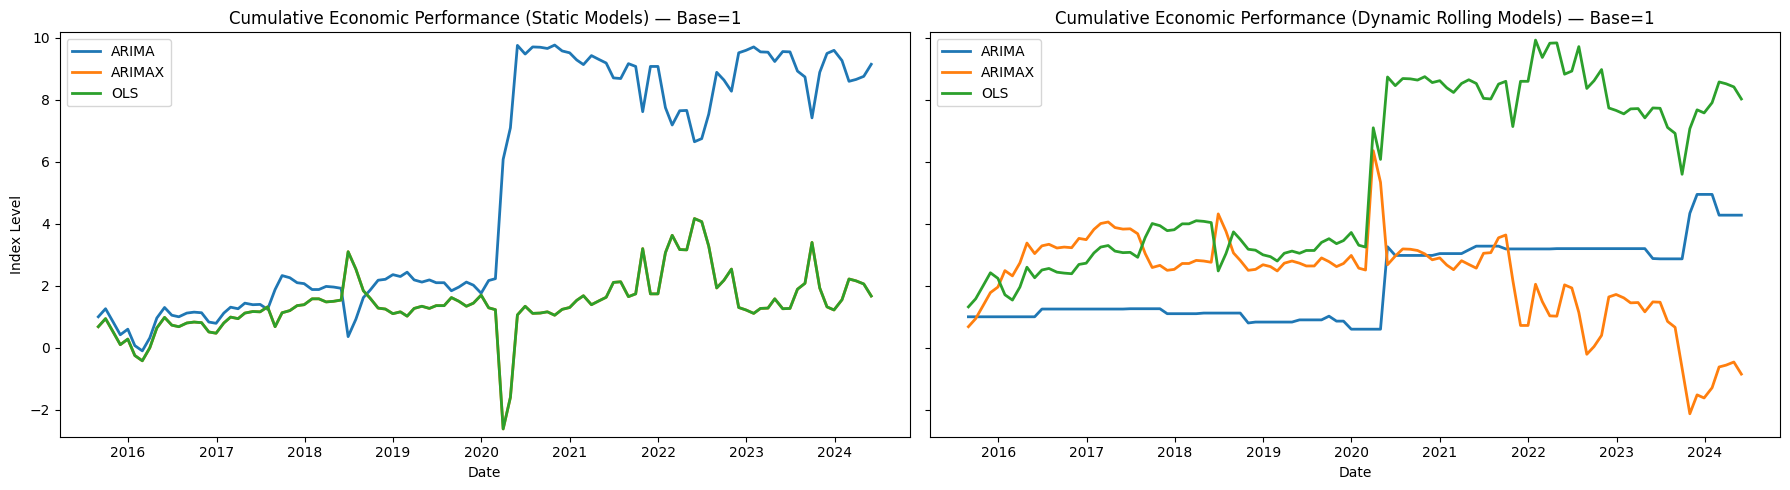

In [34]:
# ============================================================
# Two-panel equity curve plot (Static vs Dynamic)
# WITHOUT benchmarks
# SAME y-axis scale
# BASE = 1 (instead of 100)
# ============================================================

# Static equity curves
eq_arima_s, _, _  = strategy_from_forecast("ARIMA Static",  arima_static_fc,  bench_last_static, dy, STRAT_THRESHOLD, COST_BPS)
eq_arimax_s, _, _ = strategy_from_forecast("ARIMAX Static", arimax_static_fc, bench_last_static, dy, STRAT_THRESHOLD, COST_BPS)
eq_ols_s, _, _    = strategy_from_forecast("OLS Static",    ols_static_fc,    bench_last_static, dy, STRAT_THRESHOLD, COST_BPS)

# Dynamic equity curves
eq_arima_d, _, _  = strategy_from_forecast("ARIMA Dynamic",  arima_dyn_fc,  bench_last_static, dy, STRAT_THRESHOLD, COST_BPS)
eq_arimax_d, _, _ = strategy_from_forecast("ARIMAX Dynamic", arimax_dyn_fc, bench_last_static, dy, STRAT_THRESHOLD, COST_BPS)
eq_ols_d, _, _    = strategy_from_forecast("OLS Dynamic",    ols_dyn_fc,    bench_last_static, dy, STRAT_THRESHOLD, COST_BPS)

# Choose plot index (intersection to ensure all series align)
plot_idx = dy.index
for s in [eq_arima_s, eq_arimax_s, eq_ols_s, eq_arima_d, eq_arimax_d, eq_ols_d]:
    plot_idx = plot_idx.intersection(s.index)

print("plot_idx length:", len(plot_idx))

def to_index1(eq: pd.Series, idx: pd.Index) -> pd.Series:
    eq = eq.reindex(idx)
    return (1 + eq).rename(eq.name)

# Static (base = 1)
static_curves_nb = {
    "ARIMA": to_index1(eq_arima_s, plot_idx),
    "ARIMAX": to_index1(eq_arimax_s, plot_idx),
    "OLS": to_index1(eq_ols_s, plot_idx),
}

# Dynamic (base = 1)
dynamic_curves_nb = {
    "ARIMA": to_index1(eq_arima_d, plot_idx),
    "ARIMAX": to_index1(eq_arimax_d, plot_idx),
    "OLS": to_index1(eq_ols_d, plot_idx),
}

# Same y-axis scale
all_vals = np.concatenate(
    [s.values for s in list(static_curves_nb.values()) + list(dynamic_curves_nb.values())]
)
ymin = np.nanmin(all_vals)
ymax = np.nanmax(all_vals)

pad = 0.02 * (ymax - ymin) if ymax > ymin else 0.01
ymin -= pad
ymax += pad

# Plot
fig, axes = plt.subplots(1, 2, figsize=(18, 5), sharey=True)

# Static
ax = axes[0]
for name, s in static_curves_nb.items():
    ax.plot(s.index, s.values, linewidth=2, label=name)

ax.set_title("Cumulative Economic Performance (Static Models) — Base=1")
ax.set_xlabel("Date")
ax.set_ylabel("Index Level")
ax.set_ylim(ymin, ymax)
ax.legend()

# Dynamic
ax = axes[1]
for name, s in dynamic_curves_nb.items():
    ax.plot(s.index, s.values, linewidth=2, label=name)

ax.set_title("Cumulative Economic Performance (Dynamic Rolling Models) — Base=1")
ax.set_xlabel("Date")
ax.set_ylim(ymin, ymax)
ax.legend()

plt.tight_layout()
plt.show()

In [35]:
# ----------------------------
# STRATEGY PERFORMANCE TABLE (economic metrics) INCLUDING BENCHMARK MEAN ONLY
# ----------------------------
def sharpe(pnl: pd.Series) -> float:
    pnl = pnl.dropna()
    if pnl.std(ddof=1) == 0:
        return np.nan
    return float(pnl.mean() / pnl.std(ddof=1) * np.sqrt(12))  # monthly annualisation

def max_drawdown(eq: pd.Series) -> float:
    eq = eq.dropna()
    peak = eq.cummax()
    dd = eq - peak
    return float(dd.min())

econ_rows = []

strategy_dict = {
    "ARIMA Static": arima_static_fc,
    "ARIMAX Static": arimax_static_fc,
    "OLS Static": ols_static_fc,
    "ARIMA Dynamic": arima_dyn_fc,
    "ARIMAX Dynamic": arimax_dyn_fc,
    "OLS Dynamic": ols_dyn_fc,

    # Benchmark
    "Benchmark TrainMean": bench_mean_static
}

for name, fc in strategy_dict.items():
    eq, pnl, pos = strategy_from_forecast(
        name=name,
        forecast=fc,
        prev=bench_last_static,
        dy=dy,
        threshold=STRAT_THRESHOLD,
        cost_bps=COST_BPS
    )

    econ_rows.append({
        "Strategy": name,
        "Total_PnL": float(pnl.sum()),
        "Avg_PnL": float(pnl.mean()),
        "Sharpe_Ann": sharpe(pnl),
        "Max_Drawdown": max_drawdown(eq),
        "Turnover": float(pos.diff().abs().fillna(0).sum())
    })

econ_df = pd.DataFrame(econ_rows).set_index("Strategy").sort_values("Total_PnL", ascending=False)
display(econ_df)

,Total_PnL,Avg_PnL,Sharpe_Ann,Max_Drawdown,Turnover
Strategy,,,,,
ARIMA Static,8.15,0.076887,0.398089,-3.12,11.0
OLS Dynamic,7.03,0.066321,0.342426,-4.33,62.0
ARIMA Dynamic,3.28,0.030943,0.339260,-0.67,46.0
Benchmark TrainMean,3.03,0.028585,0.147000,-3.85,26.0
ARIMAX Static,0.67,0.006321,0.032477,-5.72,0.0
OLS Static,0.67,0.006321,0.032477,-5.72,0.0
ARIMAX Dynamic,-1.85,-0.017453,-0.089701,-8.49,92.0
